# Data Unterstanding - Olist Marketplace

## Zweck
Dieses Notebook dokumentiert Struktur, Beziehungen und Datenqualität der Rohdaten.

Ziel ist es zu prüfen, ob der Datensatz für eine Analyse geeignet ist.
Es werden keine Transformationen, Features oder Business-Interpretationen vorgenommen.

## 1. Datensatzüberblick

Der Datensatz enthält Transaktionsdaten eines Online-Marketplaces.
Bestellungen verbinden Kunden, Händler, Produkte, Zahlungen, Bewertungen und Lieferinformationen.

Da die Informationen auf mehrere relationale Tabellen verteilt sind, muss zunächst deren Aufbau und Zusammenhang verstanden werden.

## 2. Tabellenstruktur & Spaltenbeschreibung

### Customer/Seller/Geolocation

| Column | Description |
|------|------|
| customer_id | Kunden-Order-ID |
| customer_unique_id | Kunden-ID |
| customer_zip_code_prefix/seller_zip_code_prefix/geolocation_zip_code_prefix | Kunden/Verkäufer/Geolocation Postleitzahl |
| customer_city/seller_city/geolocation_city | Kunden/Verkäufer/Geolocation Stadt |
| customer_state/seller_state/geolocation_state | Kunden/Verkäufer/Geolocation Bundesstaat |
| seller_id | Verkäufer-ID |
| geolocation_lat | Breitengrad |
| geolocation_Ing | Längengrad |

### Products
| Column | Description |
|------|------|
| product_id | eindeutige Produkt(Item)-ID |
| product_category_name | Produkkategorie in Portugiesisch |
| product_name_lenght | Länge des Produktnames |
| product_description_lenght | Länge der Produktbeschreibung|
| product_photos_qty | Anzahl der Produktfotos|
| product_weight_g | Produktgewicht in gramm|
| product_length_cm | Produktlänge in cm|
| product_height_cm | Produkthöhe in cm|
| product_width_cm | Produktbreite in cm|


### Orders

Jede Zeile entspricht einer Bestellung.
enthält auch: customer_id

| Column | Description |
|------|------|
| order_id | eindeutige Bestell-ID |
| order_status | Bestellstatus |
| order_purchase_timestamp | Kaufzeitpunkt |
| order_approved_at | Zeitpunkt der Zahlungsgenehmigung |
| order_delivered_carrier_date | Zeipunkt an dem Bestellung an Logistikpartner übergeben wurde |
| order_delivered_customer_date | Lieferdatum |
| order_estimated_delivery_date | vorraussichtliches Lieferdatum |

### Orders_items

enthält auch: product_id, seller_id, order_id

| Column | Description |
|------|------|
| order_item_id | fortlaufende Nummer für Items IN EINER Bestellung |
| shipping_limit_date | Zeitlimit des Verkäufers für die Übergabe an den Logistikpartner |
| price | Preis des Produktes(Items) |
| freight_value | anteilige Versandkosten für dieses Item |


### Orders_Payments
enthält auch: order_id

| Column | Description |
|------|------|
| payment_sequential | Sortiert + nummeriert TEILZAHLUNGEN derselben Bestellung (1-n pro  order_id )! |
| payment_type | Zahlungsart |
| payment_installments | Ratenzahlung - Anzahl der vom Kunden gewählten Raten |
| payment_value | Zahlungswert |

### Orders_Reviews
enthält auch: order_id

| Column | Description |
|------|------|
| review_id | eindeutige Review-ID |
| review_score | Bewertung-Score - Sternebewertung 1-5|
| review_comment_title | Review Kommentar-Titel |
| review_comment_message | Review Kommentar |
| review_creation_date | Datum des Reviewerstellung |
| review_answer_timestamp | Zeitstempel der Antwort auf die Review |

Hier kommen noch kurze Übersichten rein wie head(), info(), describe()

## 3. Datenbeziehungen (Join Logic)

ER-Diagramm um alle Beziehungen zu zeigen. Liefert Wissen für zukünftige JOINs

![Olist_Marketplace.drawio (1).png](<attachment:Olist_Marketplace.drawio (1).png>)
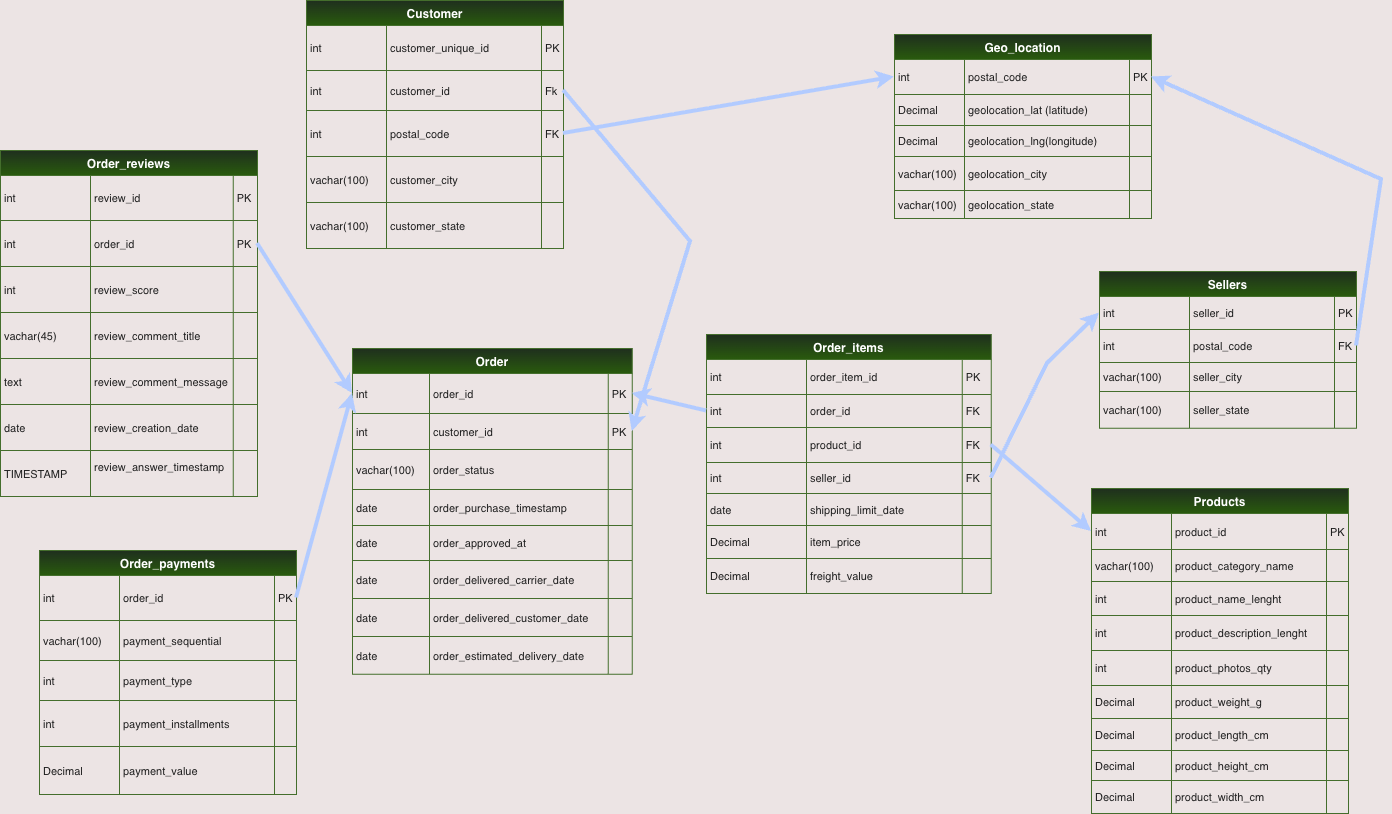

## 4. Datenqualitätsprüfung

Vor einer Analyse muss geprüft werden, ob die Daten vollständig und logisch konsistent sind.

4.1 Missing Values (Nur relevante Spalten)


4.2 Duplicates

4.3 Data Type Issues


4.4 Logical Validity Checks (Sind einzelne Werte technisch möglich?)
z.B. Lieferung vor Bestellung, negativer Preis, Bewertungen außerhalb der typsichen 1-5 Skala



## 5. Zeitliche Abdeckung

Zur Vermeidung falscher Trends muss geprüft werden,
ob der Beobachtungszeitraum vollständig und konsistent ist.


## 6. Plausibilitätsprüfung von Verteilungen

Ziel ist es festzustellen, ob die Daten realistisches Kunden- und Bestellverhalten abbilden.
Es werden keine geschäftlichen Schlussfolgerungen gezogen.

- Bewertungsverteiltung realistisch? z.B. Histogramm

- Preisverteilung z.B. Histogramm

- Lieferdauer z.B. Histogramm/Boxplot

- Bestellungen über Zeit z.B. Liniendiagramm 
-- schwankt die Nachfrage?
-- wirkt es wie echte Kundenaktivität?

## 7. Datenrisiken und Interpretationseinschränkungen

Der Datensatz bildet reale Geschäftsprozesse ab, enthält jedoch Einschränkungen, die bei späteren Auswertungen berücksichtigt werden müssen.

1. Fehlende Bewertungen
Bewertungen sind optional. Bestellungen ohne Bewertung stellen daher nicht automatisch unzufriedene Kunden dar.

    Konsequenz:
    Die durchschnittliche Bewertung kann nicht direkt als Zufriedenheitsquote interpretiert werden.

2. Mehrere Artikel pro Bestellung
Eine Bestellung kann mehrere Artikel und Händler enthalten.

    Konsequenz:
    Kennzahlen auf Bestellebene können Liefer- oder Performanceeffekte einzelner Händler verzerren.

3. Marketplace - Struktur
Die Plattform bündelt die Angebote vieler unabhängiger Händler.

    Konsequenz:
    Gesamtergebnisse spiegeln Plattform-Performance wider, nicht die Qualität eines einzelnen Anbieters.

## 8. Fazit
Struktur, Beziehungen und Datenqualität des Datensatzes wurden untersucht.

Die Daten bilden die wesentlichen Geschäftsprozesse eines Online-Marketplaces ab
und sind grundsätzlich für eine Analyse geeignet.
Allerdings liegen die Informationen verteilt über mehrere relationale Tabellen vor
und müssen zunächst zu einer auswertbaren Struktur zusammengeführt werden.

Für die weitere Analyse sind daher folgende Schritte erforderlich:

- Zusammenführung der Tabellen auf Bestell- bzw. Kundenebene
- Berechnung von Lieferdauer und Verzögerungsindikatoren
- Aggregation von Zahlungs- und Artikelinformationen
- Ableitung kundenbezogener Kennzahlen

Im nächsten Schritt wird ein analysefähiger Datensatz erstellt.